# 🚚 Predictive Maintenance Classification for a Delivery Company

## Business Objective

The goal of this project is to predict whether a device will experience a **failure**.

This is a **binary classification** problem:

- `0` = No Failure
- `1` = Failure

The dataset is highly imbalanced, so **accuracy alone is not sufficient**.  
The analysis therefore focuses especially on **Precision, Recall, F1 Score, and the Confusion Matrix** for the failure class.

The project follows this workflow:

1. Load and inspect the dataset
2. Perform exploratory data analysis
3. Prepare the features and target
4. Split the original data into training and test sets
5. Scale the training data
6. Apply **SMOTE only to the training data**
7. Compare several classification algorithms
8. Select and evaluate the best model
9. Interpret the results for predictive maintenance


## Data Dictionary

| Column | Description |
| --- | --- |
| `date` | Date on which the device data was recorded |
| `device` | Unique device identifier |
| `failure` | Target variable: 0 = No Failure, 1 = Failure |
| `attribute1` | Numerical device measurement |
| `attribute2` | Numerical device measurement |
| `attribute3` | Numerical device measurement |
| `attribute4` | Numerical device measurement |
| `attribute5` | Numerical device measurement |
| `attribute6` | Numerical device measurement |
| `attribute7` | Numerical device measurement |
| `attribute8` | Numerical device measurement |
| `attribute9` | Numerical device measurement |


## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)


## Load Dataset

In [2]:
df = pd.read_csv("failure.csv")

df.head()


,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
0,2015-01-01,S1F01085,0,215630672,56,0,52,6,407438,0,0,7
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (124494, 12)

Missing values:
date          0
device        0
failure       0
attribute1    0
attribute2    0
attribute3    0
attribute4    0
attribute5    0
attribute6    0
attribute7    0
attribute8    0
attribute9    0
dtype: int64

Duplicate rows: 0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   date        124494 non-null  str  
 1   device      124494 non-null  str  
 2   failure     124494 non-null  int64
 3   attribute1  124494 non-null  int64
 4   attribute2  124494 non-null  int64
 5   attribute3  124494 non-null  int64
 6   attribute4  124494 non-null  int64
 7   attribute5  124494 non-null  int64
 8   attribute6  124494 non-null  int64
 9   attribute7  124494 non-null  int64
 10  attribute8  124494 non-null  int64
 11  attribute9  124494 non-null  int64
dtypes: int64(10), str(2)
memory usage: 13.5 MB


## Exploratory Data Analysis

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
failure,124494.0,8.514467e-04,2.916725e-02,0.0,0.0,0.0,0.0,1.0
attribute1,124494.0,1.223868e+08,7.045960e+07,0.0,61276754.0,122795744.0,183308370.0,244140480.0
attribute2,124494.0,1.594848e+02,2.179658e+03,0.0,0.0,0.0,0.0,64968.0
attribute3,124494.0,9.940455e+00,1.857473e+02,0.0,0.0,0.0,0.0,24929.0
attribute4,124494.0,1.741120e+00,2.290851e+01,0.0,0.0,0.0,0.0,1666.0
attribute5,124494.0,1.422269e+01,1.594302e+01,1.0,8.0,10.0,12.0,98.0
attribute6,124494.0,2.601729e+05,9.915101e+04,8.0,221452.0,249799.5,310266.0,689161.0
attribute7,124494.0,2.925282e-01,7.436924e+00,0.0,0.0,0.0,0.0,832.0
attribute8,124494.0,2.925282e-01,7.436924e+00,0.0,0.0,0.0,0.0,832.0
attribute9,124494.0,1.245152e+01,1.914256e+02,0.0,0.0,0.0,0.0,18701.0


### Target Distribution

The target variable is strongly imbalanced.  
This is important because a model can achieve very high accuracy simply by predicting **No Failure** for almost every observation.


In [6]:
failure_counts = df["failure"].value_counts().sort_index()

print("Failure counts:")
print(failure_counts)

print("\nFailure percentages:")
print((df["failure"].value_counts(normalize=True).sort_index() * 100).round(4))


Failure counts:
failure
0    124388
1       106
Name: count, dtype: int64

Failure percentages:
failure
0    99.9149
1     0.0851
Name: proportion, dtype: float64


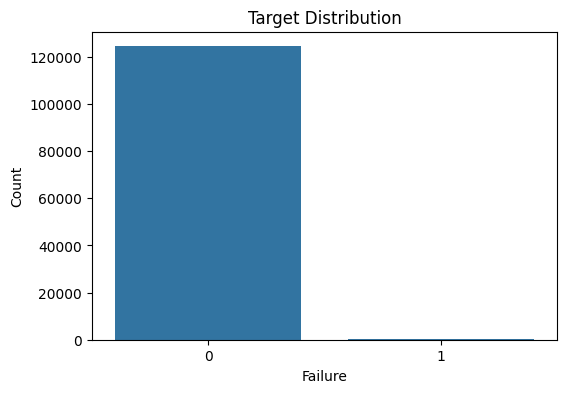

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="failure")
plt.title("Target Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()


In [8]:
majority_accuracy = (df["failure"] == 0).mean()

print(
    "Accuracy if we always predict 'No Failure':",
    round(majority_accuracy, 4)
)


Accuracy if we always predict 'No Failure': 0.9991


The majority-class baseline demonstrates why **accuracy is not enough** for this project.  
A useful predictive-maintenance model must also identify actual failures.


### Correlation Analysis

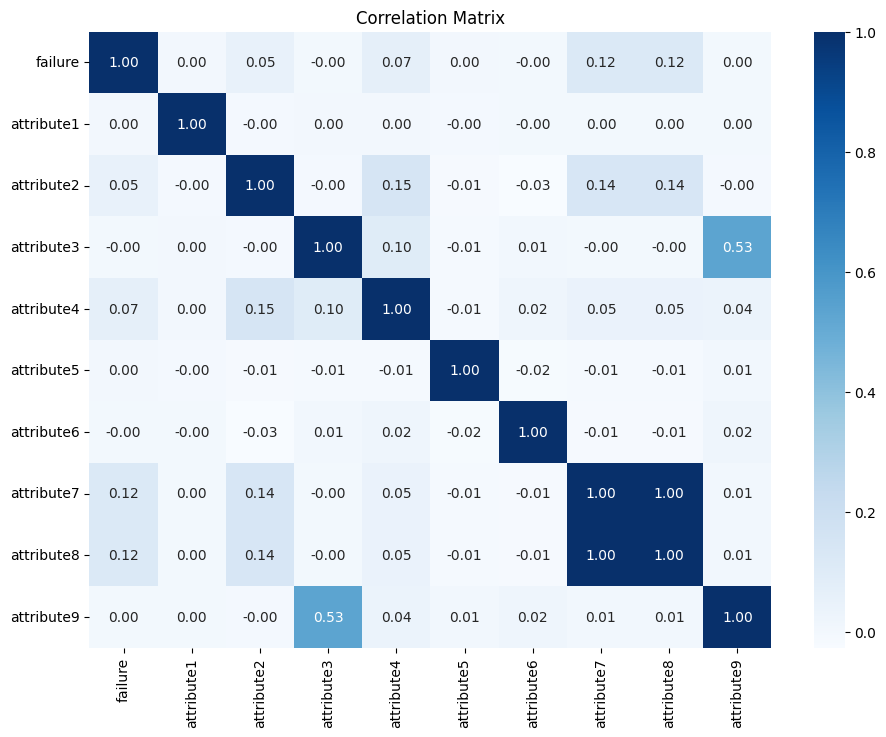

In [9]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


## Data Preparation

`device` is a unique identifier and is not used as a numerical feature.

`date` is also removed from the basic classification model so that the model is trained on the numerical device attributes.

The target variable is `failure`.


In [10]:
model_df = df.drop(columns=["date", "device"])

x = model_df.drop("failure", axis=1)
y = model_df["failure"]

print("Features:", x.shape)
print("Target:", y.shape)


Features: (124494, 9)
Target: (124494,)


## Train-Test Split

The split is performed **before SMOTE**.

`stratify=y` keeps approximately the same failure ratio in both the training and test sets.


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())


Training target distribution:
failure
0    99510
1       85
Name: count, dtype: int64

Test target distribution:
failure
0    24878
1       21
Name: count, dtype: int64


## Feature Scaling

The attributes have very different numerical ranges.

`StandardScaler` is fitted only on the training data and then applied to the test data.

Scaling is also useful before SMOTE because SMOTE creates synthetic observations using distances between samples.


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


## Handling Class Imbalance with SMOTE

SMOTE (**Synthetic Minority Over-sampling Technique**) is used to handle imbalanced classification datasets.

Instead of simply duplicating minority-class observations, SMOTE creates synthetic samples based on existing minority-class examples. This helps the model learn the minority class more effectively.

In this project, the failure class is extremely rare compared with the no-failure class. Therefore, SMOTE is applied only to the training data after the train-test split.

Applying SMOTE before splitting the dataset could cause data leakage and lead to overly optimistic model performance.

**Sources:**
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321–357.
- imbalanced-learn documentation: *Common pitfalls and recommended practices* — data leakage during resampling.

In [13]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

print("Before SMOTE:")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(Counter(y_train_smote))


Before SMOTE:
Counter({0: 99510, 1: 85})

After SMOTE:
Counter({0: 99510, 1: 99510})


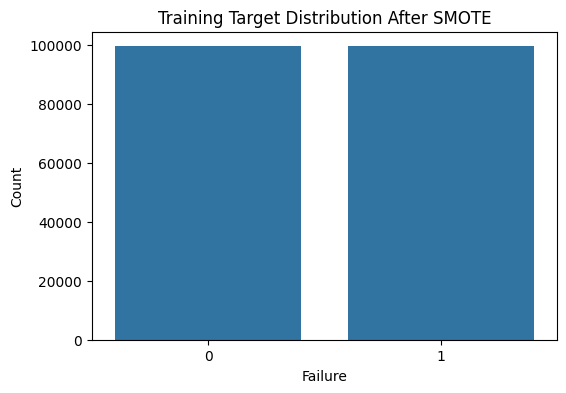

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title("Training Target Distribution After SMOTE")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()


## Classification Models

Several algorithms used in the classification lessons are compared.

Because the dataset is highly imbalanced, the model comparison focuses on the **Failure class (`1`)**:

- **Accuracy:** overall percentage of correct predictions
- **Precision:** how many predicted failures were actual failures
- **Recall:** how many actual failures were detected
- **F1 Score:** balance between Precision and Recall

For predictive maintenance, **Recall and F1 Score are especially important**, because missing a real failure can be costly.


In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

models = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        random_state=42
    ),
    "AdaBoostClassifier": AdaBoostClassifier(
        random_state=42
    )
}


In [16]:
def classification_test(
    models,
    x_train,
    y_train,
    x_test,
    y_test
):
    results = []
    fitted_models = {}

    print("Models are being trained...")

    for name, model in models.items():
        print(name)

        model.fit(x_train, y_train)
        prediction = model.predict(x_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(
                y_test,
                prediction
            ),
            "Failure Precision": precision_score(
                y_test,
                prediction,
                pos_label=1,
                zero_division=0
            ),
            "Failure Recall": recall_score(
                y_test,
                prediction,
                pos_label=1,
                zero_division=0
            ),
            "Failure F1": f1_score(
                y_test,
                prediction,
                pos_label=1,
                zero_division=0
            )
        })

        fitted_models[name] = model

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "Failure F1",
        ascending=False
    ).reset_index(drop=True)

    return results_df, fitted_models


In [17]:
results_df, fitted_models = classification_test(
    models,
    x_train_smote,
    y_train_smote,
    x_test_scaled,
    y_test
)

results_df.round(4)


Models are being trained...
GaussianNB
LogisticRegression
DecisionTreeClassifier
RandomForestClassifier
GradientBoostingClassifier
AdaBoostClassifier


,Model,Accuracy,Failure Precision,Failure Recall,Failure F1
0,RandomForestClassifier,0.9987,0.1333,0.0952,0.1111
1,DecisionTreeClassifier,0.9980,0.0882,0.1429,0.1091
2,GaussianNB,0.9882,0.0243,0.3333,0.0453
3,LogisticRegression,0.9665,0.0120,0.4762,0.0234
4,GradientBoostingClassifier,0.9660,0.0107,0.4286,0.0208
5,AdaBoostClassifier,0.9286,0.0078,0.6667,0.0155


## Model Selection

The final model is selected primarily using the **Failure F1 Score**, while also considering Failure Recall and Precision.

This is more appropriate than selecting a model only by Accuracy because the failure class is extremely rare.


In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Selected model:", best_model_name)


Selected model: RandomForestClassifier


## Final Model Evaluation

In [19]:
final_prediction = best_model.predict(
    x_test_scaled
)

print(
    classification_report(
        y_test,
        final_prediction,
        target_names=[
            "No Failure",
            "Failure"
        ],
        digits=4
    )
)


              precision    recall  f1-score   support

  No Failure     0.9992    0.9995    0.9994     24878
     Failure     0.1333    0.0952    0.1111        21

    accuracy                         0.9987     24899
   macro avg     0.5663    0.5474    0.5552     24899
weighted avg     0.9985    0.9987    0.9986     24899



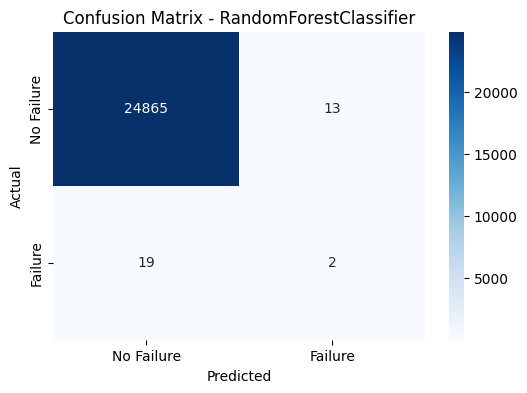

In [20]:
cm = confusion_matrix(
    y_test,
    final_prediction
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows:

- **True Negatives:** correctly predicted non-failures
- **False Positives:** devices predicted to fail although they did not fail
- **False Negatives:** actual failures that the model missed
- **True Positives:** failures correctly detected

For predictive maintenance, **False Negatives are particularly important** because they represent failures that were not detected in advance.


## Feature Importance

,Feature,Importance
3,attribute4,0.280653
1,attribute2,0.223380
4,attribute5,0.121374
5,attribute6,0.097961
0,attribute1,0.079385
7,attribute8,0.072111
6,attribute7,0.060823
8,attribute9,0.051047
2,attribute3,0.013265


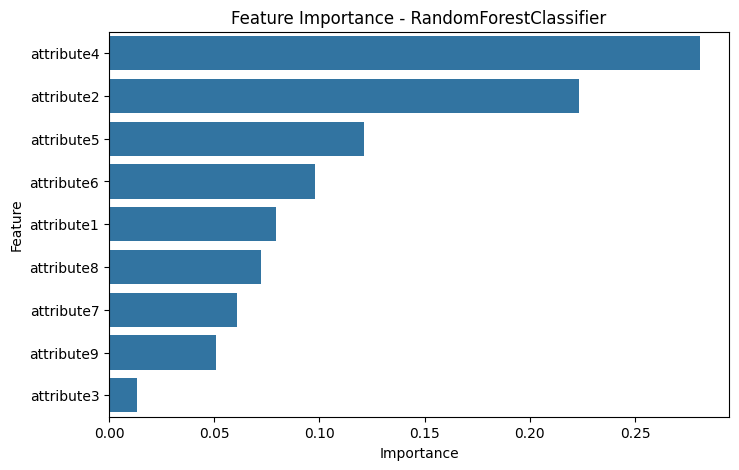

In [21]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Feature Importance - {best_model_name}"
    )
    plt.show()

else:
    print(
        best_model_name,
        "does not provide feature_importances_."
    )


## Conclusion

This project develops a binary classification workflow for predictive maintenance using device measurement data.

The main challenge of the dataset is the **extreme class imbalance** between normal observations and actual failures. For this reason, the data was first divided into training and test sets, the numerical features were scaled, and **SMOTE was applied only to the training data** to avoid data leakage.

Several classification algorithms were compared using **Accuracy, Failure Precision, Failure Recall, and Failure F1 Score**. Because failures are very rare, model selection was based primarily on the performance of the **Failure class** rather than overall Accuracy.

Among the tested models, the **Random Forest Classifier** achieved the highest Failure F1 Score and was selected as the final model.

The final test results were:

- **Accuracy:** 0.9987
- **Failure Precision:** 0.1333
- **Failure Recall:** 0.0952
- **Failure F1 Score:** 0.1111

Although the overall Accuracy is very high, the Failure Recall and F1 Score remain low. This shows that Accuracy alone can be misleading when working with a highly imbalanced dataset.

The results indicate that detecting rare failures remains challenging with the available data. Additional failure observations, feature engineering, threshold tuning, and further model optimization could improve the detection of actual failures.

Overall, the project demonstrates the importance of class-imbalance handling and appropriate evaluation metrics in predictive maintenance classification.